In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

         Target_Method     N  Total Time (ms)  ms per item
0  HashTableInitiation     1         0.000640     0.000640
1  HashTableInitiation    10         0.001050     0.000105
2  HashTableInitiation   100         0.005301     0.000053
3  HashTableInitiation  1000         0.046025     0.000046


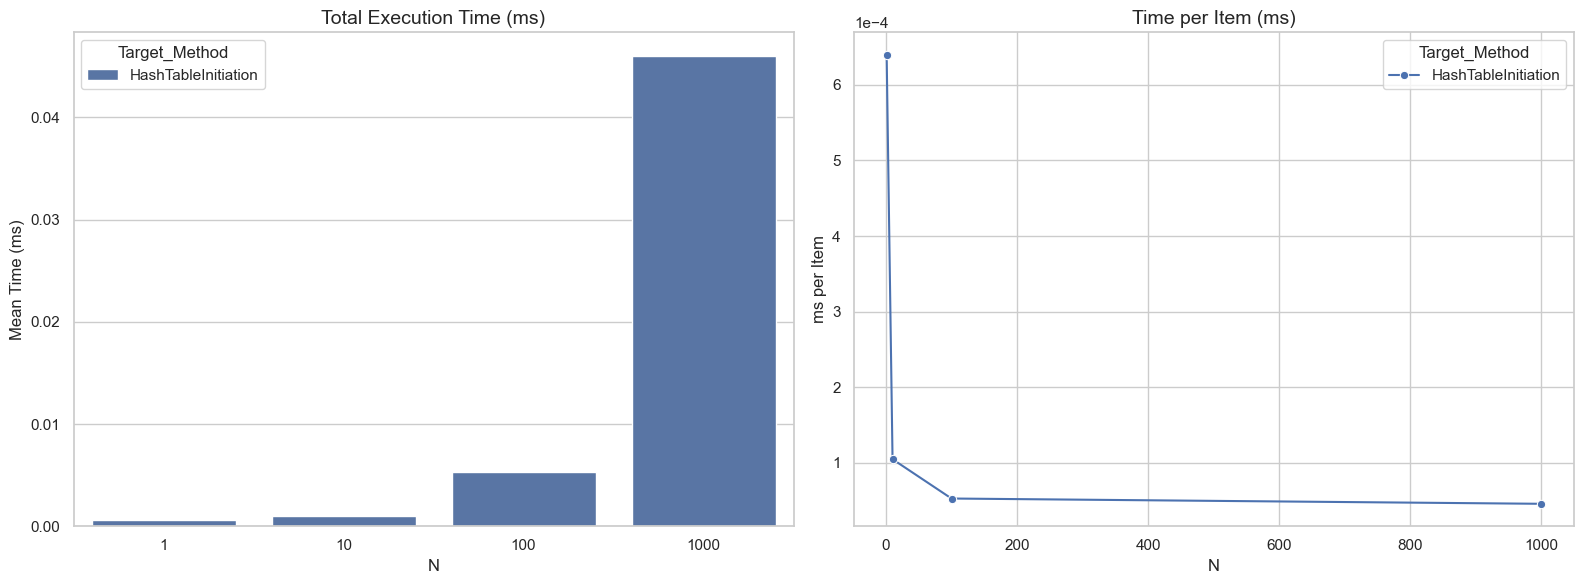

In [2]:
# Load data
df = pd.read_csv('data/hashmap/hashmap_insert_performance_data.csv')

# Extract N from Params
df['N'] = df['Params'].str.extract(r'N=(\d+)').astype(int)

# Filter for Workload Result iterations
df_res = df[(df['Measurement_IterationMode'] == 'Workload') & (df['Measurement_IterationStage'] == 'Result')]

# Aggregate means
summary = df_res.groupby(['Target_Method', 'N'])['Measurement_Value'].mean().reset_index()

# Convert ns to ms
summary['Total Time (ms)'] = summary['Measurement_Value'] / 1_000_000

# Calculate ms per item
summary['ms per item'] = summary['Total Time (ms)'] / summary['N']

# Set plotting style
sns.set_theme(style="whitegrid")

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Total Execution Time
sns.barplot(
    data=summary,
    x='N',
    y='Total Time (ms)',
    hue='Target_Method',
    ax=axes[0]
)
axes[0].set_title('Total Execution Time (ms)', fontsize=14)
axes[0].set_ylabel('Mean Time (ms)')
axes[0].set_ylim(0)

# Subplot 2: ms per item
# Using a log scale or scientific notation might be necessary given the small values
sns.lineplot(
    data=summary,
    x='N',
    y='ms per item',
    hue='Target_Method',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Time per Item (ms)', fontsize=14)
axes[1].set_ylabel('ms per Item')
#axes[1].set_xscale('log') # Better for visualizing across magnitudes of N
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('images/filter/hashmap_performance.png')

# Display the summary for the response
print(summary[['Target_Method', 'N', 'Total Time (ms)', 'ms per item']])

     Target_Method     N  Total Time (ms)  ms per item
0  HashTableLookup     1         0.000004     0.000004
1  HashTableLookup    10         0.000031     0.000003
2  HashTableLookup   100         0.000293     0.000003
3  HashTableLookup  1000         0.003337     0.000003


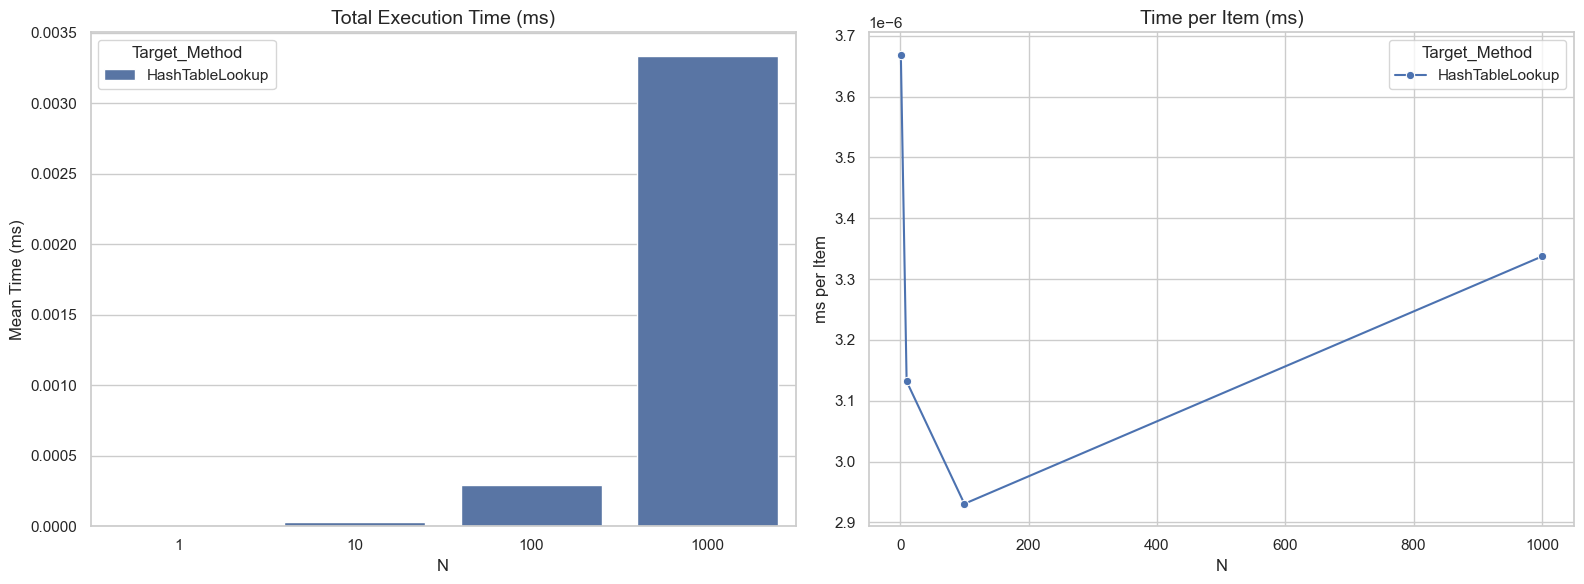

In [8]:
# Load data
df = pd.read_csv('data/hashmap/hashmap_lookup_performance_data.csv')

# Extract N from Params
df['N'] = df['Params'].str.extract(r'N=(\d+)').astype(int)

# Filter for Workload Result iterations
df_res = df[(df['Measurement_IterationMode'] == 'Workload') & (df['Measurement_IterationStage'] == 'Result')]

# Aggregate means
summary = df_res.groupby(['Target_Method', 'N'])['Measurement_Value'].mean().reset_index()

# Convert ns to ms
summary['Total Time (ms)'] = summary['Measurement_Value'] / 1_000_000

# Calculate ms per item
summary['ms per item'] = summary['Total Time (ms)'] / summary['N']

# Set plotting style
sns.set_theme(style="whitegrid")

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Total Execution Time
sns.barplot(
    data=summary,
    x='N',
    y='Total Time (ms)',
    hue='Target_Method',
    ax=axes[0]
)
axes[0].set_title('Total Execution Time (ms)', fontsize=14)
axes[0].set_ylabel('Mean Time (ms)')
axes[0].set_ylim(0)

# Subplot 2: ms per item
# Using a log scale or scientific notation might be necessary given the small values
sns.lineplot(
    data=summary,
    x='N',
    y='ms per item',
    hue='Target_Method',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Time per Item (ms)', fontsize=14)
axes[1].set_ylabel('ms per Item')
#axes[1].set_xscale('log') # Better for visualizing across magnitudes of N
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('images/hashmap/hashmap_lookup.png')

# Display the summary for the response
print(summary[['Target_Method', 'N', 'Total Time (ms)', 'ms per item']])